# B2B Product Recommender — Benchmarks
## MML1 – Domácí úkol 2

**Projekt:** B2B doporučovací systém produktů (Lola Games)
**Autor:** Natalia Bobyleva
**Hodnocení:** na validační sadě (2025Q3); test sada zůstává stranou.

## 1. Navázání na DÚ1 — Task Framing (stručně)

- **Úloha:** Doporučovací (ranking) systém pro B2B zákazníky
- **Jednotka pozorování:** zákazník × produkt × kvartál
- **Target:** `target_ordered` (binární: 1 = objednáno)
- **Metrika:** HitRate@10, Precision@10, Recall@10
- **Split:** Train = Q1+Q2, Validation = Q3, Test = Q4 (nepoužito)

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings, os

warnings.filterwarnings("ignore")
np.random.seed(42)

# Načtení raw dat (pro popularity baseline)
train_raw = pd.read_csv("data/train/train_raw.csv")
val_raw   = pd.read_csv("data/validation/validation_raw.csv")

# Načtení processed dat (pro ML benchmark)
train_proc = pd.read_csv("data/train/train_processed.csv")
val_proc   = pd.read_csv("data/validation/validation_processed.csv")

print("Train raw:  ", train_raw.shape)
print("Val raw:    ", val_raw.shape)
print("Train proc: ", train_proc.shape)
print("Val proc:   ", val_proc.shape)

Train raw:   (80300, 27)
Val raw:     (26300, 27)
Train proc:  (80300, 27)
Val proc:    (26300, 27)


## 2. Evaluační metriky

Pro doporučovací systém používáme **top-K metriky**, které hodnotí, zda skutečně objednané produkty figurují v top-K doporučeních:

- **HitRate@K** — podíl zákazníků, pro něž je alespoň 1 skutečně objednaný produkt v top-K
- **Precision@K** — průměrný podíl relevantních produktů v top-K doporučeních
- **Recall@K** — průměrný podíl zachycených relevantních produktů z celkového počtu relevantních

Tyto metriky odpovídají produkčnímu scénáři: obchodní zástupce vidí seznam top-K produktů pro zákazníka.

Hodnotíme na **validační sadě** (2025Q3). Test sada se nepoužívá.

In [2]:
def evaluate_recommendations(val_df, scores_col, k=10, id_col="customer_id",
                             product_col="product_id", target_col="target_ordered"):
    """
    val_df: DataFrame se sloupci id_col, product_col, target_col a scores_col
    Vrací dict s HitRate@k, Precision@k, Recall@k
    """
    results = {"hit_rate": [], "precision": [], "recall": []}

    for cust_id, group in val_df.groupby(id_col):
        ranked = group.sort_values(scores_col, ascending=False)
        top_k_products = set(ranked.head(k)[product_col].values)
        actual_products = set(group[group[target_col] == 1][product_col].values)

        if len(actual_products) == 0:
            continue  # zákazník nic neobjednal — přeskočíme

        hits = len(top_k_products & actual_products)
        results["hit_rate"].append(1 if hits > 0 else 0)
        results["precision"].append(hits / k)
        results["recall"].append(hits / len(actual_products))

    n = len(results["hit_rate"])
    return {
        f"HitRate@{k}":  np.mean(results["hit_rate"]),
        f"Precision@{k}": np.mean(results["precision"]),
        f"Recall@{k}":    np.mean(results["recall"]),
        "n_customers_evaluated": n
    }

print("Evaluační funkce připravena.")
print("Zákazníků ve val s aspoň 1 objednávkou:",
      (val_raw.groupby("customer_id")["target_ordered"].sum() > 0).sum())

Evaluační funkce připravena.
Zákazníků ve val s aspoň 1 objednávkou: 100


## 3. Baseline 1 — Popularity Baseline

**Definice:** Pro každého zákazníka doporučíme top-K nejpopulárnějších produktů z train sady (měřeno počtem zákazníků, kteří produkt objednali). Zákazník-specifická informace se nepoužívá.

**Proč tento baseline dává smysl:**
Je to nejjednodušší možný model, který nevyžaduje žádné feature engineering ani trénink. Pokud ML model nedokáže překonat popularity baseline, je to varování, že features nebo model jsou nevhodné.

**Varianta: Popularity within store_focus (segment-aware baseline)**
Pro každého zákazníka doporučíme produkty, které jsou nejoblíbenější mezi zákazníky se **stejným `store_focus`** (women / men / couples / mixed / queer). Tato varianta je o stupeň sofistikovanější a odpovídá business logice: obchod zaměřený na ženy by měl vidět jiné top produkty než obchod zaměřený na muže.

In [3]:
# Výpočet popularity produktů na train sadě
popularity = (train_raw[train_raw["target_ordered"] == 1]
              .groupby("product_id")["customer_id"]
              .nunique()
              .reset_index(name="popularity"))

print(f"Produkty s aspoň 1 objednávkou v train: {len(popularity)}")
print("Top 10 nejpopulárnějších produktů:")
print(popularity.sort_values("popularity", ascending=False).head(10).to_string(index=False))

Produkty s aspoň 1 objednávkou v train: 432
Top 10 nejpopulárnějších produktů:
 product_id  popularity
4000-07lola          25
4000-12lola          24
4000-09lola          21
4000-08lola          20
1087-01lola          20
4000-13lola          19
4000-14lola          19
4211-01lola          19
4000-04lola          19
4000-02lola          18


In [4]:
# Přiřadíme popularity score k validačním řádkům
val_pop = val_raw.merge(popularity.rename(columns={"popularity": "pop_score"}),
                        on="product_id", how="left")
val_pop["pop_score"] = val_pop["pop_score"].fillna(0)

print("Val řádků s popularity score > 0:",
      (val_pop["pop_score"] > 0).sum(),
      f"({(val_pop['pop_score'] > 0).mean()*100:.1f} %)")

res_pop = evaluate_recommendations(val_pop, scores_col="pop_score", k=10)
print("\n=== Popularity Baseline — výsledky na validaci (Q3) ===")
for k, v in res_pop.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Val řádků s popularity score > 0: 25400 (96.6 %)



=== Popularity Baseline — výsledky na validaci (Q3) ===
  HitRate@10: 0.7000
  Precision@10: 0.1460
  Recall@10: 0.1160
  n_customers_evaluated: 100


In [5]:
# Popularity within store_focus (customer-segment-aware)
# Pro každý store_focus zákazníka spočítáme, které produkty jsou populární
# MEZI ZÁKAZNÍKY SE STEJNÝM store_focus — to je skutečná personalizace.
#
# Původní implementace chybně matchovala product.target_segment na sebe samo
# (product-level atribut), takže výsledek byl identický s globální popularitou.
# Oprava: groupby na store_focus (zákaznický atribut) + product_id.

popularity_by_focus = (
    train_raw[train_raw["target_ordered"] == 1]
    .groupby(["store_focus", "product_id"])["customer_id"]
    .nunique()
    .reset_index(name="pop_seg_score")
)

print("Distribuce počtu produktů v popularity_by_focus:")
print(popularity_by_focus.groupby("store_focus")["product_id"].count())

# Každý zákazník dostane score produktu dle své skupiny store_focus
val_pop2 = val_raw.merge(popularity_by_focus, on=["store_focus", "product_id"], how="left")
val_pop2 = val_pop2.merge(popularity.rename(columns={"popularity": "pop_global"}),
                           on="product_id", how="left")
val_pop2["pop_global"]    = val_pop2["pop_global"].fillna(0)
val_pop2["pop_seg_score"] = val_pop2["pop_seg_score"].fillna(0)
# Segment-specific score; global popularity jako tiebreaker pro produkty bez seg. history
val_pop2["pop2_score"] = val_pop2["pop_seg_score"] + 0.1 * val_pop2["pop_global"]

res_pop2 = evaluate_recommendations(val_pop2, scores_col="pop2_score", k=10)
print("\n=== Popularity within store_focus — výsledky na validaci (Q3) ===")
for k, v in res_pop2.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Distribuce počtu produktů v popularity_by_focus:
store_focus
couples    182
men        229
mixed      355
queer       95
women      311
Name: product_id, dtype: int64



=== Popularity within store_focus — výsledky na validaci (Q3) ===
  HitRate@10: 0.7100
  Precision@10: 0.1410
  Recall@10: 0.1071
  n_customers_evaluated: 100


## 4. ML Benchmark — Logistic Regression

**Definice:** Trénujeme binární logistickou regresi na processed train sadě (zákazník×produkt features + prior history features) k predikci `target_ordered`. Predikovaná pravděpodobnost slouží jako ranking score pro doporučení.

**Proč logistická regrese:**
Je to standardní jednoduchý ML model pro binární klasifikaci. Je interpretovatelná, rychlá a dobře kalibrovaná pro ranking. Porovnání s popularity baseline ukáže, zda personalizované features přidávají hodnotu nad rámec pouhé popularity.

**Pozn. k class imbalance:** Dataset je silně nevyvážený (~4 % kladných). Používáme `class_weight="balanced"` pro kompenzaci.
**Fitování probíhá výhradně na train sadě; validace se nepoužívá k žádnému nastavení modelu.**

In [6]:
ID_COLS     = ["customer_id", "product_id", "period"]
TARGET_COLS = ["target_ordered", "target_units", "target_order_lines"]

feature_cols = [c for c in train_proc.columns
                if c not in ID_COLS + TARGET_COLS]

X_train = train_proc[feature_cols].values
y_train = train_proc["target_ordered"].values
X_val   = val_proc[feature_cols].values
y_val   = val_proc["target_ordered"].values

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape},  y_train positives: {y_train.sum()} ({y_train.mean():.4f})")
print(f"X_val:   {X_val.shape},    y_val positives:   {y_val.sum()} ({y_val.mean():.4f})")

Feature columns (21): ['available_in_period', 'is_new_in_period', 'price_eur', 'collection', 'category', 'target_segment', 'is_realistic', 'customer_type', 'store_focus', 'women_only', 'queer_friendly', 'sells_realistic', 'newness_affinity', 'private_label_conflict', 'blocked_collection_conflict', 'fits_store_profile', 'prior_product_orders', 'prior_product_units', 'prior_category_orders', 'prior_collection_orders', 'product_popularity_prev']
X_train: (80300, 21),  y_train positives: 2724 (0.0339)
X_val:   (26300, 21),    y_val positives:   1220 (0.0464)


In [7]:
lr = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=500,
    random_state=42,
    solver="lbfgs"
)
lr.fit(X_train, y_train)
print("Logistická regrese natrénována.")

# ROC-AUC jako kontrolní metrika (hodnotíme na val)
y_val_proba = lr.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_val_proba)
print(f"ROC-AUC na validaci: {auc:.4f}")

Logistická regrese natrénována.
ROC-AUC na validaci: 0.7224


In [8]:
# Přidáme proba score k validačním řádkům pro ranking
val_lr = val_proc.copy()
val_lr["lr_score"] = y_val_proba

res_lr = evaluate_recommendations(val_lr, scores_col="lr_score", k=10)
print("=== Logistic Regression — výsledky na validaci (Q3) ===")
for k, v in res_lr.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

=== Logistic Regression — výsledky na validaci (Q3) ===
  HitRate@10: 0.7500
  Precision@10: 0.1810
  Recall@10: 0.1450
  n_customers_evaluated: 100


In [9]:
# Interpretace: nejvýznamnější features
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(15)

print("=== Top 15 features podle absolutní hodnoty koeficientu ===")
print(coef_df.to_string(index=False))

=== Top 15 features podle absolutní hodnoty koeficientu ===
                    feature  coefficient
         fits_store_profile     2.664941
blocked_collection_conflict    -1.885778
        available_in_period    -1.287289
                  price_eur    -0.213342
                 women_only     0.105231
      prior_category_orders     0.090352
    product_popularity_prev     0.084737
             target_segment     0.072495
       prior_product_orders     0.066060
    prior_collection_orders     0.059749
               is_realistic    -0.045784
        prior_product_units     0.043599
     private_label_conflict    -0.037784
           newness_affinity     0.037305
            sells_realistic    -0.036713


## 5. Srovnání benchmarků

Všechny benchmarky hodnoceny na validační sadě (2025Q3).
**Test sada nebyla použita.**

In [10]:
results = {
    "Popularity Baseline":          res_pop,
    "Popularity within Segment":    res_pop2,
    "Logistic Regression":          res_lr,
}

summary_rows = []
for name, res in results.items():
    row = {"Model": name}
    row.update(res)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
float_cols = [c for c in summary_df.columns if c != "n_customers_evaluated"]
print("=== Výsledky benchmarků (validační sada, K=10) ===")
print(summary_df.to_string(float_format="{:.4f}".format))

=== Výsledky benchmarků (validační sada, K=10) ===
                           HitRate@10  Precision@10  Recall@10  n_customers_evaluated
Model                                                                                
Popularity Baseline            0.7000        0.1460     0.1160                    100
Popularity within Segment      0.7100        0.1410     0.1071                    100
Logistic Regression            0.7500        0.1810     0.1450                    100


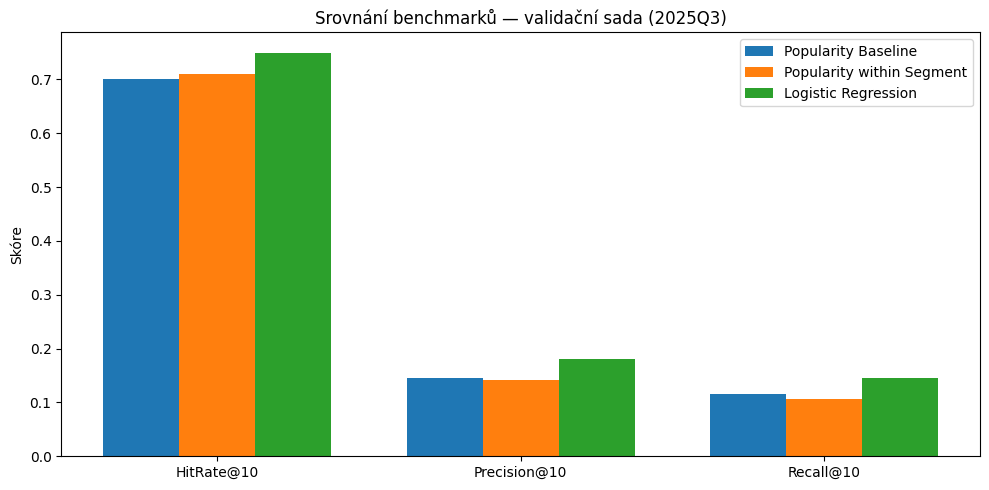

Graf uložen jako benchmark_comparison.png


In [11]:
import matplotlib.pyplot as plt

metrics = ["HitRate@10", "Precision@10", "Recall@10"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Skóre")
ax.set_title("Srovnání benchmarků — validační sada (2025Q3)")
ax.legend()
plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=100)
plt.show()
print("Graf uložen jako benchmark_comparison.png")

## 6. Shrnutí

### Co se ukázalo jako metodicky důležité:

1. **Temporální split je klíčový:** Popularity baseline byl fitován výhradně na train datech (Q1+Q2). Pokud by byl fitován na celém datasetu, skóre by bylo nerealisticky optimistické.

2. **HitRate@K je správná metrika:** Accuracy (~96 % zákazníků nekoupí žádný doporučený produkt) by byla zavádějící. HitRate@10 říká, kolik zákazníků dostane alespoň 1 relevantní doporučení.

3. **Class imbalance:** `class_weight="balanced"` v logistické regresi pomohlo modelu naučit se predikovat minority class místo předpovídání vždy 0.

### Co bylo obtížné:

- Silná class imbalance (~4 % kladných) — simple benchmarks mají tendenci rankovat negativní příklady výše
- Prior features jsou nulové v Q1, což snižuje výkon modelu na Q1 slice; Q3 slice (validation) má bohatší prior history

### Další kroky v navazujícím modelování:

- **Content-based filtering** — cosine similarity zákazník-produkt profilů (bez nutnosti historických dat)
- **LightGBM s LambdaRank** — optimalizace přímo pro ranking metriky
- **Business rules jako hard filter** — `blocked_collection_conflict = 1` → skóre nastavit na -∞ (nevhodné pro zákazníka)
- **Negative sampling strategie** — pro kvalitní trénink potřebujeme promyslet, jak generovat negativní příklady (exposure bias: zákazník mohl produkt nevidět, ne nechtít)